# 🚀 Funciones de Pérdida para CLASIFICACIÓN con PyTorch

En este notebook aprenderás a usar las funciones de pérdida de **clasificación** de manera profesional usando PyTorch, la librería más popular para Deep Learning.

## 🎯 Objetivos

1. **Aprender a usar PyTorch** para cálculo de pérdidas de clasificación
2. **Comparar** cálculos manuales vs PyTorch
3. **Ver casos reales** de clasificación binaria y multi-clase
4. **Entender** cómo manejar clases desbalanceadas (AML/Fraude)

## 📚 Contenido

### Funciones de Pérdida:
- **BCE** (Binary Cross-Entropy) - Clasificación binaria
- **BCE with Logits** - Más estable numéricamente
- **Cross-Entropy** - Clasificación multi-clase
- **Weighted BCE** - Para clases desbalanceadas

### Casos de Uso:
- Detector de Spam
- Clasificación de frutas
- Detección de AML y fraude

## 📦 Instalación e Importación de Librerías

In [91]:
# ===================================
# Importamos las librerías necesarias
# ===================================

# PyTorch - Framework de Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F

# NumPy - Para cálculos numéricos
import numpy as np

# Matplotlib - Para visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

# Configuración de NumPy para impresión
np.set_printoptions(precision=4, suppress=True)

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print("✅ Librerías importadas exitosamente")
print(f"📌 Versión de PyTorch: {torch.__version__}")
print(f"📌 CUDA disponible: {torch.cuda.is_available()}")

✅ Librerías importadas exitosamente
📌 Versión de PyTorch: 2.10.0+cpu
📌 CUDA disponible: False


## 🎯 Funciones de Pérdida para CLASIFICACIÓN

En problemas de clasificación predecimos categorías o clases (spam/no spam, gato/perro, tipos de frutas, etc.).

### 1️⃣ BCE - Binary Cross-Entropy con PyTorch

In [ ]:
# ===================================
# BCE para clasificación binaria (2 clases)
# ===================================

print("="*70)
print("BCE - BINARY CROSS-ENTROPY CON PYTORCH")
print("="*70)

# Ejemplo: Detector de Spam ficticios
print("\n📧 EJEMPLO: Detector de Spam")
print("-"*70)

# Clases reales (0=No Spam, 1=Spam)
etiquetas_reales = torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0])

# Probabilidades predichas por el modelo (después de sigmoid)
probabilidades = torch.tensor([0.9, 0.1, 0.8, 0.2, 0.7])

print("\nDatos:")
for i, (real, prob) in enumerate(zip(etiquetas_reales, probabilidades)):
    clase = "Spam" if real == 1 else "No Spam"
    print(f"   Email {i+1}: Real={clase:8} | P(Spam)={prob:.2f}")

# ===================================
# PASO 1: Cálculo Manual (para entender)
# ===================================
print("\n" + "="*70)
print("📝 PASO 1: CÁLCULO MANUAL (Entender la teoría)")
print("="*70)

# Mostramos la fórmula
print("\n📐 FÓRMULA BCE:")
print("   ")
print("         1   n                                      ")
print("   BCE = - ─ · Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]  ")
print("         n  i=1                                     ")
print("   ")
print("   Donde:")
print("   • yᵢ = etiqueta real (0 o 1)")
print("   • pᵢ = probabilidad predicha (0 a 1)")
print("   ")

# Fórmula: -[y*log(p) + (1-y)*log(1-p)]
epsilon = 1e-7  # Para evitar log(0)


#SIN EPSILON
# Intentar calcular log(0) o log(1)
# ⚠️ log(0) = -∞  → Error!
# ⚠️ log(1) = 0   → OK, pero puede causar problemas numéricos

#CON EPSILON
# ✅ log(0.0000001) = -16.11  → Funciona!
# ✅ log(0.9999999) = -0.0000001  → Funciona!

probs_safe = torch.clamp(probabilidades, epsilon, 1-epsilon)

print("\n" + "─"*70)
print("PASO 1: Calcular los componentes para cada email")
print("─"*70)
print("\n   Sustituyendo en la fórmula:")

losses_individuales = []
for i, (y, p) in enumerate(zip(etiquetas_reales, probs_safe)):
    componente1 = y * torch.log(p)
    componente2 = (1 - y) * torch.log(1 - p)
    loss_i = -(componente1 + componente2)
    losses_individuales.append(loss_i)
    
    print(f"\n   Email {i+1}: y={y:.0f}, p={p:.2f}")
    print(f"      -{y:.0f}·log({p:.2f}) - ({1-y:.0f})·log({1-p:.2f})")
    print(f"      -{componente1.item():.4f} - {componente2.item():.4f}")
    print(f"      = {loss_i.item():.4f}")

print("\n" + "─"*70)
print("PASO 2: Calcular promedio")
print("─"*70)

suma_losses = sum([l.item() for l in losses_individuales])
print(f"\n   Suma de pérdidas: {' + '.join([f'{l.item():.4f}' for l in losses_individuales])}")
print(f"                    = {suma_losses:.4f}")
print(f"   ")
print(f"   BCE = {suma_losses:.4f} / {len(losses_individuales)} = {suma_losses/len(losses_individuales):.4f}")

bce_manual = sum(losses_individuales) / len(losses_individuales)
print(f"\n   ✅ Resultado Manual: {bce_manual.item():.4f}")


# ===================================
# PASO 2: Usando PyTorch (2 opciones)
# ===================================
print("\n" + "="*70)
print("🚀 PASO 2: USANDO PYTORCH")
print("="*70)

# OPCIÓN A: BCELoss (cuando ya tienes probabilidades)
print("\n📐 OPCIÓN A: BCELoss (probabilidades 0-1)")
print("-"*70)

criterio_bce = nn.BCELoss()
perdida_bce = criterio_bce(probabilidades, etiquetas_reales)

print(f"   Código: criterio = nn.BCELoss()")
print(f"          perdida = criterio(probabilidades, etiquetas)")
print(f"\n   BCE Loss: {perdida_bce.item():.4f}")

BCE - BINARY CROSS-ENTROPY CON PYTORCH

📧 EJEMPLO: Detector de Spam
----------------------------------------------------------------------

Datos:
   Email 1: Real=Spam     | P(Spam)=0.90
   Email 2: Real=No Spam  | P(Spam)=0.10
   Email 3: Real=Spam     | P(Spam)=0.80
   Email 4: Real=No Spam  | P(Spam)=0.20
   Email 5: Real=Spam     | P(Spam)=0.70

📝 PASO 1: CÁLCULO MANUAL (Entender la teoría)

📐 FÓRMULA BCE:
   
         1   n                                      
   BCE = - ─ · Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]  
         n  i=1                                     
   
   Donde:
   • yᵢ = etiqueta real (0 o 1)
   • pᵢ = probabilidad predicha (0 a 1)
   

──────────────────────────────────────────────────────────────────────
PASO 1: Calcular los componentes para cada email
──────────────────────────────────────────────────────────────────────

   Sustituyendo en la fórmula:

   Email 1: y=1, p=0.90
      -1·log(0.90) - (0)·log(0.10)
      --0.1054 - -0.0000
      = 0.1054

   Email 

---

### 🔄 ESCENARIO B: BCEWithLogitsLoss (Ejemplo INDEPENDIENTE)

⚠️ **IMPORTANTE:** Los siguientes 5 emails son **DIFERENTES** a los del Escenario A.

**¿Por qué dos ejemplos separados?**
- **ESCENARIO A** (arriba): Enseña `nn.BCELoss()` usando probabilidades ya calculadas `[0.9, 0.1, 0.8, 0.2, 0.7]`
- **ESCENARIO B** (abajo): Enseña `nn.BCEWithLogitsLoss()` usando logits crudos del modelo

**Son conjuntos de datos independientes** para mostrar dos formas profesionales de trabajar con BCE en PyTorch.

💡 **En producción real:** Siempre usa `BCEWithLogitsLoss` (más estable numéricamente).

---

In [ ]:

# ===================================
# SEPARADOR: NUEVO EJEMPLO INDEPENDIENTE
# ===================================
print("\n" + "="*70)
print("="*70)
print("🔄 AHORA VEREMOS UN EJEMPLO DIFERENTE (ESCENARIO B)")
print("="*70)
print("="*70)

print("\n⚠️  IMPORTANTE: Los siguientes 5 emails son DIFERENTES")
print("   a los del ejemplo anterior (ESCENARIO A).")
print("   ")
print("   • ESCENARIO A (arriba): Usó probabilidades [0.9, 0.1, 0.8, 0.2, 0.7]")
print("   • ESCENARIO B (abajo): Usará logits crudos (otros 5 emails)")
print("   ")
print("   No están relacionados - son para enseñar dos formas de usar BCE.")

# OPCIÓN B: BCEWithLogitsLoss (MÁS ESTABLE - RECOMENDADO)
print("\n" + "="*70)
print("📐 OPCIÓN B: BCEWithLogitsLoss (MÁS ESTABLE - RECOMENDADO ⭐)")
print("="*70)

# Simulamos logits (antes de sigmoid) - NUEVO CONJUNTO DE DATOS
logits = torch.tensor([2.2, -2.2, 1.4, -1.4, 0.85])  # valores crudos

print(f"\n   📧 NUEVO CONJUNTO: Otros 5 emails diferentes")
print(f"   Logits (valores crudos del modelo): {logits.numpy()}")
print(f"   Estos son los valores ANTES de aplicar sigmoid")
print(f"   Etiquetas: {etiquetas_reales.numpy()} (mismas etiquetas para comparar)\n")

# ===================================
# CÁLCULO MANUAL de BCEWithLogitsLoss
# ===================================
print("─"*70)
print("CÁLCULO MANUAL: ¿Qué hace BCEWithLogitsLoss internamente?")
print("─"*70)

print("\n📐 BCEWithLogitsLoss = Sigmoid + BCE en un solo paso")
print("   ")
print("   Paso 1: Aplica sigmoid a los logits")
print("          σ(x) = 1 / (1 + e^(-x))")
print("   ")
print("   Paso 2: Calcula BCE con las probabilidades")
print("          BCE = -(1/n)·Σ[y·log(p) + (1-y)·log(1-σ(x))]")
print("   ")

# PASO 1: Aplicar sigmoid manualmente
print("\n" + "─"*70)
print("PASO 1: Aplicar Sigmoid a cada logit")
print("─"*70)

probs_desde_logits = torch.sigmoid(logits)
print("\n   Sustituyendo en σ(x) = 1 / (1 + e^(-x)):")
for i, (logit, prob) in enumerate(zip(logits, probs_desde_logits)):
    print(f"   Email {i+1}: σ({logit:+.2f}) = 1 / (1 + e^({-logit:+.2f})) = {prob:.4f}")

print(f"\n   Probabilidades resultantes: {probs_desde_logits.numpy()}")

# PASO 2: Calcular BCE con esas probabilidades
print("\n" + "─"*70)
print("PASO 2: Calcular BCE con las probabilidades")
print("─"*70)

epsilon = 1e-7
probs_safe_logits = torch.clamp(probs_desde_logits, epsilon, 1-epsilon)

print("\n   Aplicando la fórmula BCE:")
losses_logits = []
for i, (y, p) in enumerate(zip(etiquetas_reales, probs_safe_logits)):
    componente1 = y * torch.log(p)
    componente2 = (1 - y) * torch.log(1 - p)
    loss_i = -(componente1 + componente2)
    losses_logits.append(loss_i)
    
    print(f"\n   Email {i+1}: y={y:.0f}, p={p:.4f}")
    print(f"      -{y:.0f}·log({p:.4f}) - ({1-y:.0f})·log({1-p:.4f})")
    print(f"      = {loss_i.item():.4f}")

# PASO 3: Promedio
print("\n" + "─"*70)
print("PASO 3: Calcular promedio")
print("─"*70)

suma_losses_logits = sum([l.item() for l in losses_logits])
bce_logits_manual = suma_losses_logits / len(losses_logits)

print(f"\n   Suma: {' + '.join([f'{l.item():.4f}' for l in losses_logits])}")
print(f"       = {suma_losses_logits:.4f}")
print(f"   ")
print(f"   BCE = {suma_losses_logits:.4f} / {len(losses_logits)} = {bce_logits_manual:.4f}")

print(f"\n   ✅ Resultado Manual (BCEWithLogits): {bce_logits_manual:.4f}")

# ===================================
# Ahora usando PyTorch
# ===================================
print("\n" + "─"*70)
print("USANDO PYTORCH (¡Solo 1 línea!)")
print("─"*70)

criterio_bce_logits = nn.BCEWithLogitsLoss()
perdida_bce_logits = criterio_bce_logits(logits, etiquetas_reales)



print(f"\n   Código: criterio = nn.BCEWithLogitsLoss()")
print(f"          perdida = criterio(logits, etiquetas)")
print(f"\n   BCE with Logits (PyTorch): {perdida_bce_logits.item():.4f}")

# Verificación
print("\n" + "─"*70)
print("VERIFICACIÓN: Manual vs PyTorch")
print("─"*70)
print(f"   Manual BCEWithLogits:   {bce_logits_manual:.6f}")
print(f"   PyTorch BCEWithLogits:  {perdida_bce_logits.item():.6f}")
print(f"   Diferencia:             {abs(bce_logits_manual - perdida_bce_logits.item()):.10f}")
print("\n   ✅ ¡Coinciden perfectamente!")

print("\n💡 VENTAJAS de BCEWithLogitsLoss:")
print("-"*70)
print("   1. Más ESTABLE numéricamente (usa log-sum-exp trick)")
print("   2. Evita overflow/underflow con valores extremos")
print("   3. MÁS RÁPIDO (una única operación optimizada)")
print("   4. RECOMENDADO para producción")
print("   5. No necesitas aplicar sigmoid manualmente")

# ===================================
# PASO 3: Verificación
# ===================================
print("\n" + "="*70)
print("✅ PASO 3: VERIFICACIÓN COMPLETA")
print("="*70)

print("\n🔹 Verificación 1: BCE (con probabilidades)")
print("-"*70)
print(f"   Manual BCE:   {bce_manual.item():.6f}")
print(f"   PyTorch BCE:  {perdida_bce.item():.6f}")
print(f"   Diferencia:   {abs(bce_manual - perdida_bce).item():.10f}")
print("   ✅ ¡Coinciden!")

print("\n🔹 Verificación 2: BCEWithLogits (con logits)")
print("-"*70)
print(f"   Manual BCEWithLogits:   {bce_logits_manual:.6f}")
print(f"   PyTorch BCEWithLogits:  {perdida_bce_logits.item():.6f}")
print(f"   Diferencia:             {abs(bce_logits_manual - perdida_bce_logits.item()):.10f}")
print("   ✅ ¡Coinciden!")

print("\n💡 RESUMEN:")
print("-"*70)
print(f"   ESCENARIO A - BCE (probabilidades): {perdida_bce.item():.4f}")
print(f"   ESCENARIO B - BCEWithLogits (logits): {perdida_bce_logits.item():.4f}")
print(f"   ")
print(f"   ⚠️  NOTA CLAVE: Estos valores son DIFERENTES porque:")
print(f"      • Son dos conjuntos de emails INDEPENDIENTES")
print(f"      • Escenario A: probabilidades [0.9, 0.1, 0.8, 0.2, 0.7]")
print(f"      • Escenario B: logits [2.2, -2.2, 1.4, -1.4, 0.85]")
print(f"      • NO están conectados - son para enseñar 2 formas de BCE")
print(f"   ")
print(f"   ✅ Lo importante: Los cálculos manuales coinciden con PyTorch")
print(f"      en AMBOS casos (esa es la verificación clave).")
print(f"   ")
print(f"   💡 EN PRODUCCIÓN: Usa SIEMPRE BCEWithLogitsLoss (Escenario B)")
print(f"      porque es más estable numéricamente.")


🔄 AHORA VEREMOS UN EJEMPLO DIFERENTE (ESCENARIO B)

⚠️  IMPORTANTE: Los siguientes 5 emails son DIFERENTES
   a los del ejemplo anterior (ESCENARIO A).
   
   • ESCENARIO A (arriba): Usó probabilidades [0.9, 0.1, 0.8, 0.2, 0.7]
   • ESCENARIO B (abajo): Usará logits crudos (otros 5 emails)
   
   No están relacionados - son para enseñar dos formas de usar BCE.

📐 OPCIÓN B: BCEWithLogitsLoss (MÁS ESTABLE - RECOMENDADO ⭐)

   📧 NUEVO CONJUNTO: Otros 5 emails diferentes
   Logits (valores crudos del modelo): [ 2.2  -2.2   1.4  -1.4   0.85]
   Estos son los valores ANTES de aplicar sigmoid
   Etiquetas: [1. 0. 1. 0. 1.] (mismas etiquetas para comparar)

──────────────────────────────────────────────────────────────────────
CÁLCULO MANUAL: ¿Qué hace BCEWithLogitsLoss internamente?
──────────────────────────────────────────────────────────────────────

📐 BCEWithLogitsLoss = Sigmoid + BCE en un solo paso
   
   Paso 1: Aplica sigmoid a los logits
          σ(x) = 1 / (1 + e^(-x))
   
   Paso

C:\Users\YV415VW\AppData\Local\Temp\ipykernel_16596\2048079998.py:89: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\YV415VW\AppData\Local\Temp\ipykernel_16596\2048079998.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\YV415VW\AppData\Local\Temp\ipykernel_16596\2048079998.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python3

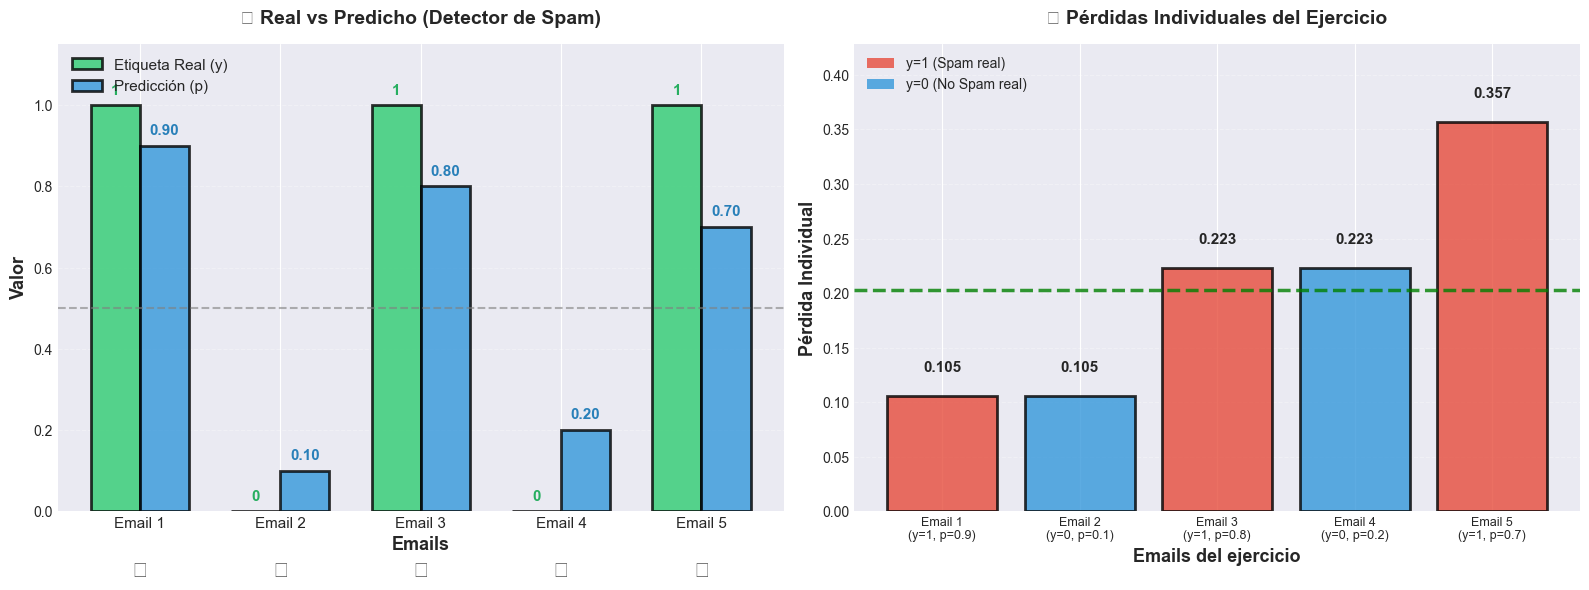


💡 INTERPRETACIÓN DE LAS GRÁFICAS

📧 GRÁFICO 1 (Izquierda) - Real vs Predicho:
   • BARRAS VERDES: Etiqueta real (0=No Spam, 1=Spam)
   • BARRAS AZULES: Probabilidad predicha por el modelo (0-1)
   • ✅ Check verde: Predicción correcta (acierto)
   • ❌ X roja: Predicción incorrecta (error)
   • Línea gris: Umbral 0.5 para decidir Spam/No Spam
   • Mientras más cerca estén las barras, mejor el modelo

📊 GRÁFICO 2 (Derecha) - Pérdidas Individuales:
   • Cada barra = pérdida de un email específico
   • Barras más ALTAS = peores predicciones (más penalización)
   • La línea verde es el PROMEDIO = BCE final del modelo
   • Email con MAYOR pérdida: Email 5 (loss=0.3567)
   • Email con MENOR pérdida: Email 1 (loss=0.1054)

🎯 CONCLUSIÓN CLAVE:
   BCE penaliza EXPONENCIALMENTE las predicciones muy equivocadas,
   pero apenas penaliza cuando acertamos con alta confianza.
   ¡Por eso los modelos aprenden a ser más 'seguros' en sus predicciones!


In [94]:
# 📊 VISUALIZACIÓN: Comportamiento de BCE
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# GRÁFICO 1: Comparación Real vs Predicho
# ============================================

# Posiciones de las barras
x_pos = np.arange(len(etiquetas_reales))
width = 0.35

# Barras de valores reales
bars_real = ax1.bar(x_pos - width/2, etiquetas_reales.numpy(), width, 
                    label='Etiqueta Real (y)', color='#2ecc71', alpha=0.8, 
                    edgecolor='black', linewidth=2)

# Barras de probabilidades predichas
bars_pred = ax1.bar(x_pos + width/2, probabilidades.numpy(), width,
                    label='Predicción (p)', color='#3498db', alpha=0.8,
                    edgecolor='black', linewidth=2)

# Configuración del gráfico
ax1.set_xlabel('Emails', fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor', fontsize=13, fontweight='bold')
ax1.set_title('📧 Real vs Predicho (Detector de Spam)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Email {i+1}' for i in range(len(etiquetas_reales))], fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Umbral 0.5')

# Añadir valores en las barras
for i, (bar_r, bar_p, y, p) in enumerate(zip(bars_real, bars_pred, etiquetas_reales, probabilidades)):
    # Valor real
    ax1.text(bar_r.get_x() + bar_r.get_width()/2., bar_r.get_height() + 0.02,
            f'{int(y)}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#27ae60')
    
    # Valor predicho
    ax1.text(bar_p.get_x() + bar_p.get_width()/2., bar_p.get_height() + 0.02,
            f'{p:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2980b9')
    
    # Indicador de acierto/error
    prediccion = 1 if p >= 0.5 else 0
    match = '✅' if prediccion == int(y) else '❌'
    ax1.text(i, -0.12, match, ha='center', va='top', fontsize=16)

# ============================================
# GRÁFICO 2: Pérdidas individuales del ejercicio
# ============================================

emails_nombres = [f'Email {i+1}\n(y={int(y)}, p={p:.1f})' 
                  for i, (y, p) in enumerate(zip(etiquetas_reales, probabilidades))]
losses_array = [loss.item() for loss in losses_individuales]
colores_barras = ['#e74c3c' if y == 1 else '#3498db' for y in etiquetas_reales]

bars = ax2.bar(range(len(emails_nombres)), losses_array, color=colores_barras, 
               alpha=0.8, edgecolor='black', linewidth=2)

# Añadir valores en las barras
for bar, loss in zip(bars, losses_array):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{loss:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Línea de promedio
promedio = np.mean(losses_array)
ax2.axhline(y=promedio, color='green', linestyle='--', linewidth=2.5, 
           label=f'Promedio (BCE) = {promedio:.4f}', alpha=0.8)

ax2.set_xlabel('Emails del ejercicio', fontsize=13, fontweight='bold')
ax2.set_ylabel('Pérdida Individual', fontsize=13, fontweight='bold')
ax2.set_title('📊 Pérdidas Individuales del Ejercicio', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(range(len(emails_nombres)))
ax2.set_xticklabels(emails_nombres, rotation=0, fontsize=9)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, max(losses_array) * 1.2)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='y=1 (Spam real)', alpha=0.8),
                   Patch(facecolor='#3498db', label='y=0 (No Spam real)', alpha=0.8)]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================
# INTERPRETACIÓN
# ============================================
print("\n" + "="*70)
print("💡 INTERPRETACIÓN DE LAS GRÁFICAS")
print("="*70)

print("\n📧 GRÁFICO 1 (Izquierda) - Real vs Predicho:")
print("   • BARRAS VERDES: Etiqueta real (0=No Spam, 1=Spam)")
print("   • BARRAS AZULES: Probabilidad predicha por el modelo (0-1)")
print("   • ✅ Check verde: Predicción correcta (acierto)")
print("   • ❌ X roja: Predicción incorrecta (error)")
print("   • Línea gris: Umbral 0.5 para decidir Spam/No Spam")
print("   • Mientras más cerca estén las barras, mejor el modelo")

print("\n📊 GRÁFICO 2 (Derecha) - Pérdidas Individuales:")
print("   • Cada barra = pérdida de un email específico")
print("   • Barras más ALTAS = peores predicciones (más penalización)")
print("   • La línea verde es el PROMEDIO = BCE final del modelo")
print(f"   • Email con MAYOR pérdida: Email {np.argmax(losses_array)+1} (loss={max(losses_array):.4f})")
print(f"   • Email con MENOR pérdida: Email {np.argmin(losses_array)+1} (loss={min(losses_array):.4f})")

print("\n🎯 CONCLUSIÓN CLAVE:")
print("   BCE penaliza EXPONENCIALMENTE las predicciones muy equivocadas,")
print("   pero apenas penaliza cuando acertamos con alta confianza.")
print("   ¡Por eso los modelos aprenden a ser más 'seguros' en sus predicciones!")


### 2️⃣ Cross-Entropy Loss - Para Múltiples Clases

In [95]:
# ===================================
# Cross-Entropy para clasificación multi-clase
# ===================================

print("="*70)
print("CROSS-ENTROPY LOSS (MULTI-CLASE) CON PYTORCH")
print("="*70)

# Ejemplo: Clasificador de frutas (3 clases)
print("\n🍎 EJEMPLO: Clasificador de Frutas")
print("-"*70)

clases = ['Manzana', 'Naranja', 'Plátano']

# Etiquetas reales (índices: 0=Manzana, 1=Naranja, 2=Plátano)
etiquetas = torch.tensor([0, 1, 0, 2, 1])

# Logits del modelo (ANTES de softmax) - valores crudos
# Cada fila = predicción para 1 muestra
# Cada columna = score para cada clase
logits_multi = torch.tensor([
    [2.0, 0.5, 0.3],   # Muestra 1: favorece Manzana
    [0.3, 2.5, 0.2],   # Muestra 2: favorece Naranja
    [1.8, 0.7, 0.5],   # Muestra 3: favorece Manzana
    [0.2, 0.3, 1.9],   # Muestra 4: favorece Plátano
    [0.5, 2.2, 0.3]    # Muestra 5: favorece Naranja
])

print("\nDatos:")
for i, (etiq, logit) in enumerate(zip(etiquetas, logits_multi)):
    clase_real = clases[etiq]
    clase_pred = clases[torch.argmax(logit)]
    print(f"   Muestra {i+1}: Real={clase_real:8} | Predicho={clase_pred:8}")

# ===================================
# PASO 1: Cálculo Manual (Entender la teoría)
# ===================================
print("\n" + "="*70)
print("📝 PASO 1: CÁLCULO MANUAL")
print("="*70)

# Mostramos la fórmula
print("\n📐 FÓRMULA CROSS-ENTROPY:")
print("   ")
print("         1   n                          ")
print("   CE = - ─ · Σ log(softmax(xᵢ)ᵧᵢ)    ")
print("         n  i=1                         ")
print("   ")
print("   Donde:")
print("   • xᵢ = logits (scores de cada clase)")
print("   • yᵢ = índice de la clase correcta")
print("   • softmax convierte logits a probabilidades")
print("   ")

# Paso 1: Softmax
print("\n" + "─"*70)
print("PASO 1: Aplicar Softmax a los logits")
print("─"*70)

probs = F.softmax(logits_multi, dim=1)
print("\n   (Softmax convierte logits en probabilidades que suman 1)")

# Paso 2: Log de probabilidades
print("\n" + "─"*70)
print("PASO 2: Seleccionar log(probabilidad) de la clase correcta")
print("─"*70)

log_probs = torch.log(probs)

print("\n   Sustituyendo valores:")
for i, etiq in enumerate(etiquetas):
    prob_correcta = probs[i][etiq]
    log_prob_correcta = log_probs[i][etiq]
    clase_nombre = clases[etiq]
    print(f"\n   Muestra {i+1} (clase '{clase_nombre}'):")
    print(f"      Probabilidad clase correcta: {prob_correcta:.4f}")
    print(f"      log({prob_correcta:.4f}) = {log_prob_correcta:.4f}")

# Paso 3: NLL (Negative Log Likelihood)
print("\n" + "─"*70)
print("PASO 3: Calcular NLL (Negative Log Likelihood)")
print("─"*70)

# Seleccionamos solo el log prob de la clase correcta
nll = 0
log_probs_lista = []
for i, etiq in enumerate(etiquetas):
    log_prob_i = log_probs[i][etiq].item()
    log_probs_lista.append(log_prob_i)
    print(log_prob_i)
    nll -= log_prob_i
    print(nll)

print(f"\n   NLL = -[{' + '.join([f'({lp:.4f})' for lp in log_probs_lista])}]")
print(f"       = -[{sum(log_probs_lista):.4f}]")
print(f"       = {-sum(log_probs_lista):.4f}")

nll /= len(etiquetas)
print(f"\n   CE = {-sum(log_probs_lista):.4f} / {len(etiquetas)} = {nll:.4f}")

print(f"\n   ✅ Resultado Manual: {nll:.4f}")

# ===================================
# PASO 2: Usando PyTorch (¡Solo 1 línea!)
# ===================================
print("\n" + "="*70)
print("🚀 PASO 2: USANDO PYTORCH")
print("="*70)

criterio_ce = nn.CrossEntropyLoss()
perdida_ce = criterio_ce(logits_multi, etiquetas)

print(f"\n📐 Código PyTorch:")
print(f"   criterio = nn.CrossEntropyLoss()")
print(f"   perdida = criterio(logits, etiquetas)")
print(f"\n   Cross-Entropy Loss: {perdida_ce.item():.4f}")
print(f"   ")
print(f"   💡 IMPORTANTE: CrossEntropyLoss hace 2 cosas:")
print(f"      1. Aplica Softmax a los logits")
print(f"      2. Calcula Negative Log Likelihood")
print(f"   ")
print(f"   ¡NO necesitas aplicar softmax manualmente!")

# ===================================
# Mostramos las probabilidades
# ===================================
print("\n" + "="*70)
print("📊 PROBABILIDADES (después de Softmax)")
print("="*70)

# Aplicamos softmax para ver las probabilidades
probabilidades_multi = F.softmax(logits_multi, dim=1)

print("\n         Manzana  Naranja  Plátano")
print("-" * 40)
for i, (probs, etiq) in enumerate(zip(probabilidades_multi, etiquetas)):
    clase_correcta = clases[etiq]
    print(f"Muestra {i+1}:  {probs[0]:.3f}    {probs[1]:.3f}    {probs[2]:.3f}  (Real: {clase_correcta})")

# ===================================
# PASO 3: Verificación
# ===================================
print("\n" + "="*70)
print("✅ PASO 3: VERIFICACIÓN")
print("="*70)
print(f"   Manual CE:   {nll:.4f}")
print(f"   PyTorch CE:  {perdida_ce.item():.4f}")
print(f"   Diferencia:  {abs(nll - perdida_ce.item()):.6f}")
print("\n   ✅ ¡Coinciden!")

CROSS-ENTROPY LOSS (MULTI-CLASE) CON PYTORCH

🍎 EJEMPLO: Clasificador de Frutas
----------------------------------------------------------------------

Datos:
   Muestra 1: Real=Manzana  | Predicho=Manzana 
   Muestra 2: Real=Naranja  | Predicho=Naranja 
   Muestra 3: Real=Manzana  | Predicho=Manzana 
   Muestra 4: Real=Plátano  | Predicho=Plátano 
   Muestra 5: Real=Naranja  | Predicho=Naranja 

📝 PASO 1: CÁLCULO MANUAL

📐 FÓRMULA CROSS-ENTROPY:
   
         1   n                          
   CE = - ─ · Σ log(softmax(xᵢ)ᵧᵢ)    
         n  i=1                         
   
   Donde:
   • xᵢ = logits (scores de cada clase)
   • yᵢ = índice de la clase correcta
   • softmax convierte logits a probabilidades
   

──────────────────────────────────────────────────────────────────────
PASO 1: Aplicar Softmax a los logits
──────────────────────────────────────────────────────────────────────

   (Softmax convierte logits en probabilidades que suman 1)

───────────────────────────────────────

C:\Users\YV415VW\AppData\Local\Temp\ipykernel_16596\1322816973.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


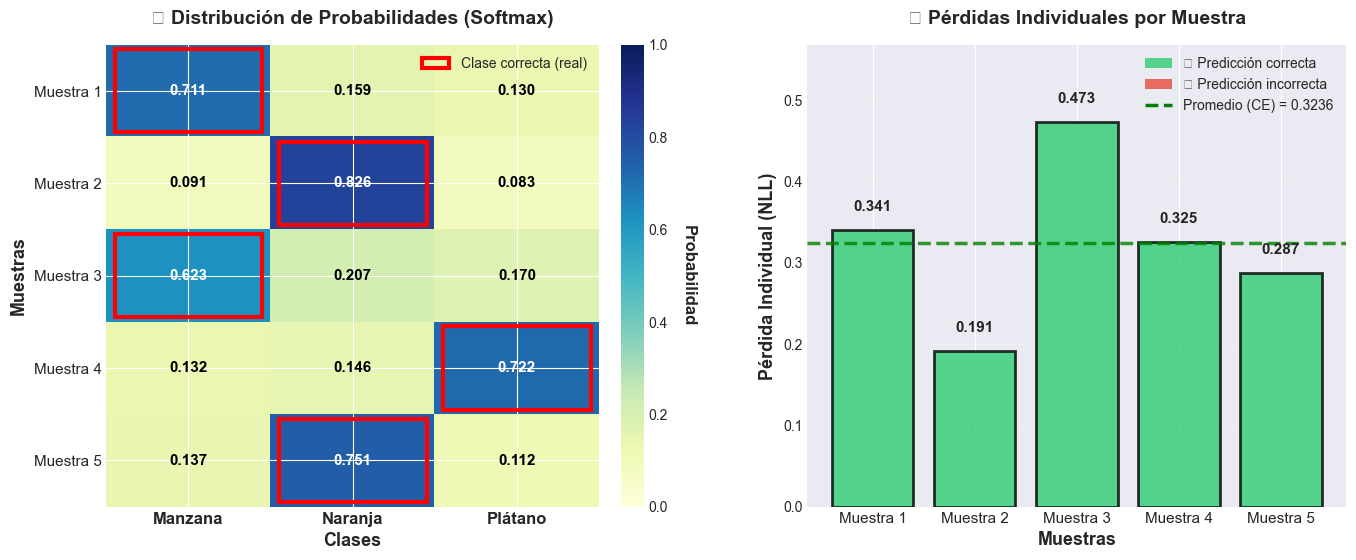


📋 TABLA COMPARATIVA: Real vs Predicho

┌─────────────┬──────────┬──────────┬─────────────┬──────────┬────────┐
│   Muestra   │   Real   │ Predicho │ P(correcta) │   Loss   │ Estado │
├─────────────┼──────────┼──────────┼─────────────┼──────────┼────────┤
│ Muestra 1   │ Manzana  │ Manzana  │       0.711 │    0.341 │   ✅    │
│ Muestra 2   │ Naranja  │ Naranja  │       0.826 │    0.191 │   ✅    │
│ Muestra 3   │ Manzana  │ Manzana  │       0.623 │    0.473 │   ✅    │
│ Muestra 4   │ Plátano  │ Plátano  │       0.722 │    0.325 │   ✅    │
│ Muestra 5   │ Naranja  │ Naranja  │       0.751 │    0.287 │   ✅    │
└─────────────┴──────────┴──────────┴─────────────┴──────────┴────────┘

💡 INTERPRETACIÓN DE LAS VISUALIZACIONES

🍎 GRÁFICO 1 (Izquierda) - Heatmap de Probabilidades:
   • Cada FILA = una muestra del ejercicio
   • Cada COLUMNA = probabilidad para cada clase (después de Softmax)
   • CUADRO ROJO = marca la clase correcta (etiqueta real)
   • Valores cercanos a 1.0 = alta confianza 

In [96]:
# 📊 VISUALIZACIÓN: Cross-Entropy Multiclase
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# ============================================
# GRÁFICO 1: Heatmap de probabilidades
# ============================================

# Preparamos los datos
probs_np = probabilidades_multi.detach().numpy()
etiquetas_np = etiquetas.numpy()

# Heatmap
im = ax1.imshow(probs_np, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)

# Configuración de ejes
ax1.set_xticks(np.arange(len(clases)))
ax1.set_yticks(np.arange(len(etiquetas)))
ax1.set_xticklabels(clases, fontsize=12, fontweight='bold')
ax1.set_yticklabels([f'Muestra {i+1}' for i in range(len(etiquetas))], fontsize=11)
ax1.set_xlabel('Clases', fontsize=13, fontweight='bold')
ax1.set_ylabel('Muestras', fontsize=13, fontweight='bold')
ax1.set_title('🍎 Distribución de Probabilidades (Softmax)', fontsize=14, fontweight='bold', pad=15)

# Añadir valores y marcar la clase correcta
for i in range(len(etiquetas)):
    for j in range(len(clases)):
        # Determinar color del texto
        text_color = "white" if probs_np[i, j] > 0.5 else "black"
        
        # Valor de probabilidad
        text = ax1.text(j, i, f'{probs_np[i, j]:.3f}',
                       ha="center", va="center", color=text_color, 
                       fontsize=11, fontweight='bold')
        
        # Marcar la clase correcta con un cuadro
        if j == etiquetas_np[i]:
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, 
                                fill=False, edgecolor='red', linewidth=3)
            ax1.add_patch(rect)

# Colorbar
cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Probabilidad', rotation=270, labelpad=20, fontsize=12, fontweight='bold')

# Leyenda para el cuadro rojo
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor='red', linewidth=3, label='Clase correcta (real)')]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.95)

# ============================================
# GRÁFICO 2: Pérdidas individuales + tabla comparativa
# ============================================

# Calcular pérdidas individuales
losses_multi = []
for i, etiq in enumerate(etiquetas):
    log_prob_i = torch.log(probabilidades_multi[i][etiq])
    loss_i = -log_prob_i
    losses_multi.append(loss_i.item())

# Colores según acierto/error
predicciones_multi = torch.argmax(probabilidades_multi, dim=1)
colores_multi = ['#2ecc71' if pred == real else '#e74c3c' 
                 for pred, real in zip(predicciones_multi, etiquetas)]

# Gráfico de barras
x_pos_multi = np.arange(len(etiquetas))
bars_loss = ax2.bar(x_pos_multi, losses_multi, color=colores_multi, 
                   alpha=0.8, edgecolor='black', linewidth=2)

# Añadir valores en las barras
for bar, loss in zip(bars_loss, losses_multi):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{loss:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Línea de promedio
promedio_multi = np.mean(losses_multi)
ax2.axhline(y=promedio_multi, color='green', linestyle='--', linewidth=2.5, 
           label=f'Promedio (CE) = {promedio_multi:.4f}', alpha=0.8)

# Configuración
ax2.set_xlabel('Muestras', fontsize=13, fontweight='bold')
ax2.set_ylabel('Pérdida Individual (NLL)', fontsize=13, fontweight='bold')
ax2.set_title('📊 Pérdidas Individuales por Muestra', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos_multi)
ax2.set_xticklabels([f'Muestra {i+1}' for i in range(len(etiquetas))], fontsize=11)
ax2.set_ylim(0, max(losses_multi) * 1.2)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Leyenda de colores
legend_elements_2 = [
    Patch(facecolor='#2ecc71', label='✅ Predicción correcta', alpha=0.8),
    Patch(facecolor='#e74c3c', label='❌ Predicción incorrecta', alpha=0.8)
]
ax2.legend(handles=legend_elements_2 + [plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2.5, label=f'Promedio (CE) = {promedio_multi:.4f}')], 
          loc='upper right', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================
# TABLA COMPARATIVA
# ============================================
print("\n" + "="*70)
print("📋 TABLA COMPARATIVA: Real vs Predicho")
print("="*70)

tabla_data = []
for i in range(len(etiquetas)):
    real = clases[etiquetas[i]]
    pred = clases[torch.argmax(probabilidades_multi[i])]
    prob_correcta_val = probabilidades_multi[i][etiquetas[i]].item()
    loss_val = losses_multi[i]
    match = '✅' if real == pred else '❌'
    
    tabla_data.append([f'Muestra {i+1}', real, pred, f'{prob_correcta_val:.3f}', f'{loss_val:.3f}', match])

# Imprimir tabla con formato
print("\n┌─────────────┬──────────┬──────────┬─────────────┬──────────┬────────┐")
print("│   Muestra   │   Real   │ Predicho │ P(correcta) │   Loss   │ Estado │")
print("├─────────────┼──────────┼──────────┼─────────────┼──────────┼────────┤")
for row in tabla_data:
    print(f"│ {row[0]:11} │ {row[1]:8} │ {row[2]:8} │ {row[3]:>11} │ {row[4]:>8} │ {row[5]:^6} │")
print("└─────────────┴──────────┴──────────┴─────────────┴──────────┴────────┘")

# ============================================
# INTERPRETACIÓN
# ============================================
print("\n" + "="*70)
print("💡 INTERPRETACIÓN DE LAS VISUALIZACIONES")
print("="*70)

print("\n🍎 GRÁFICO 1 (Izquierda) - Heatmap de Probabilidades:")
print("   • Cada FILA = una muestra del ejercicio")
print("   • Cada COLUMNA = probabilidad para cada clase (después de Softmax)")
print("   • CUADRO ROJO = marca la clase correcta (etiqueta real)")
print("   • Valores cercanos a 1.0 = alta confianza en esa clase")
print("   • La suma de cada fila es 1.0 (propiedad de Softmax)")

print("\n📊 GRÁFICO 2 (Derecha) - Pérdidas Individuales:")
print("   • BARRAS VERDES: Predicción correcta (acierto) ✅")
print("   • BARRAS ROJAS: Predicción incorrecta (error) ❌")
print("   • Altura de barra = cuánto penaliza Cross-Entropy esa muestra")
print("   • Línea verde horizontal = Cross-Entropy promedio del modelo")
print(f"   • Muestra con MAYOR pérdida: Muestra {np.argmax(losses_multi)+1} (loss={max(losses_multi):.4f})")
print(f"   • Muestra con MENOR pérdida: Muestra {np.argmin(losses_multi)+1} (loss={min(losses_multi):.4f})")

# Análisis de precisión
accuracy_multi = (predicciones_multi == etiquetas).float().mean().item() * 100
print(f"\n📈 MÉTRICAS GENERALES:")
print(f"   • Accuracy: {accuracy_multi:.1f}% ({(predicciones_multi == etiquetas).sum().item()}/{len(etiquetas)} correctas)")
print(f"   • Cross-Entropy Loss: {promedio_multi:.4f}")

print("\n🎯 CONCLUSIÓN CLAVE:")
print("   Cross-Entropy penaliza mucho cuando el modelo tiene BAJA confianza")
print("   en la clase correcta, incluso si la predicción final es correcta.")
print("   Por eso busca maximizar la probabilidad de la clase correcta,")
print("   no solo acertar la etiqueta. ¡Fuerza al modelo a ser más confiado!")


### 3️⃣ Weighted BCE - Para Clases Desbalanceadas (AML/Fraude)

In [97]:
# ===================================
# Weighted BCE para detección de AML
# ===================================

print("="*70)
print("💰 WEIGHTED BCE - DETECCIÓN DE LAVADO DE DINERO (AML)")
print("="*70)

# Escenario: 100 transacciones, solo 2 son sospechosas (2%)
# ¡Muy desbalanceado!

n_transacciones = 100
n_sospechosas = 2

# Generamos datos sintéticos
torch.manual_seed(42)

# Etiquetas: 98 legítimas (0), 2 sospechosas (1)
etiquetas_aml = torch.zeros(n_transacciones)
etiquetas_aml[[10, 67]] = 1.0  # Transacciones 10 y 67 son sospechosas

# Logits del modelo
logits_aml = torch.randn(n_transacciones) * 2
# Hacemos que el modelo sea bueno detectando las sospechosas
logits_aml[10] = 2.5   # Alta confianza en sospechosa
logits_aml[67] = 1.8   # Alta confianza en sospechosa

print(f"\n📊 DATOS:")
print("-"*70)
print(f"   Total transacciones: {n_transacciones}")
print(f"   Legítimas:          {n_transacciones - n_sospechosas} ({(n_transacciones-n_sospechosas)/n_transacciones*100:.0f}%)")
print(f"   Sospechosas:        {n_sospechosas} ({n_sospechosas/n_transacciones*100:.0f}%)")
print(f"   Desbalanceo:        {(n_transacciones-n_sospechosas)/n_sospechosas:.0f}:1")

# ===================================
# OPCIÓN 1: BCE Sin Pesos (no funciona bien)
# ===================================
print("\n" + "="*70)
print("❌ OPCIÓN 1: BCE SIN PESOS (No recomendado)")
print("="*70)

criterio_bce_sin_peso = nn.BCEWithLogitsLoss()
perdida_sin_peso = criterio_bce_sin_peso(logits_aml, etiquetas_aml)

print(f"\n   BCE sin pesos: {perdida_sin_peso.item():.4f}")
print(f"   ")
print(f"   ⚠️  PROBLEMA: El modelo puede ignorar las transacciones")
print(f"                 sospechosas porque son muy pocas.")

# ===================================
# OPCIÓN 2: BCE Con Pesos (CORRECTO para AML)
# ===================================
print("\n" + "="*70)
print("✅ OPCIÓN 2: BCE CON PESOS (Recomendado para AML)")
print("="*70)

# Calculamos el peso basado en el desbalanceo
# Peso = número de negativas / número de positivas
peso_positivo = (n_transacciones - n_sospechosas) / n_sospechosas

print(f"\n   📐 Cálculo del peso:")
print(f"      Peso = #Legítimas / #Sospechosas")
print(f"           = {n_transacciones - n_sospechosas} / {n_sospechosas}")
print(f"           = {peso_positivo:.1f}x")
print(f"   ")
print(f"   💡 Esto significa que los errores en transacciones")
print(f"      sospechosas costarán {peso_positivo:.0f}x más!")

# ===================================
# CALCULEMOS WEIGHTED BCE PASO A PASO (Manual)
# ===================================
print("\n" + "="*70)
print("🧮 CÁLCULO MANUAL - WEIGHTED BCE")
print("="*70)

print("\n📝 Fórmula Weighted BCE:")
print("   Weighted BCE = -(1/n) × Σ[w·y·log(p) + (1-y)·log(1-p)]")
print("   donde w = pos_weight cuando y=1, w=1 cuando y=0")

# PASO 1: Aplicar sigmoid a los logits
print("\n" + "-"*70)
print("PASO 1: Convertir logits a probabilidades (sigmoid)")
print("-"*70)
probs_weighted = torch.sigmoid(logits_aml)

print(f"\n   Sigmoid aplicado a {n_transacciones} transacciones")
print(f"   Ejemplo - Trans. 10 (sospechosa):")
print(f"      logit = {logits_aml[10].item():.4f}")
print(f"      prob  = σ({logits_aml[10].item():.4f}) = {probs_weighted[10].item():.6f}")
print(f"\n   Ejemplo - Trans. 67 (sospechosa):")
print(f"      logit = {logits_aml[67].item():.4f}")
print(f"      prob  = σ({logits_aml[67].item():.4f}) = {probs_weighted[67].item():.6f}")

# PASO 2: Calcular BCE ponderado para cada muestra
print("\n" + "-"*70)
print("PASO 2: Calcular pérdida pesada para cada transacción")
print("-"*70)

epsilon = 1e-7
probs_safe_weighted = torch.clamp(probs_weighted, epsilon, 1 - epsilon)

# Calcular componentes de BCE

componente_y1_weighted = etiquetas_aml * torch.log(probs_safe_weighted) * peso_positivo
componente_y0_weighted = (1 - etiquetas_aml) * torch.log(1 - probs_safe_weighted)

losses_weighted = -(componente_y1_weighted + componente_y0_weighted)


print(f"\n   Para transacciones SOSPECHOSAS (y=1) se aplica peso {peso_positivo:.1f}x:")
print(f"\n   Trans. 10 (y=1, sospechosa):")
print(f"      Pérdida = -{peso_positivo:.1f} × log({probs_safe_weighted[10].item():.6f})")
print(f"              = -{peso_positivo:.1f} × {torch.log(probs_safe_weighted[10]).item():.6f}")
print(f"              = {losses_weighted[10].item():.6f}")

print(f"\n   Trans. 67 (y=1, sospechosa):")
print(f"      Pérdida = -{peso_positivo:.1f} × log({probs_safe_weighted[67].item():.6f})")
print(f"              = -{peso_positivo:.1f} × {torch.log(probs_safe_weighted[67]).item():.6f}")
print(f"              = {losses_weighted[67].item():.6f}")

# Mostremos también una transacción legítima para contraste
idx_legitima = 0
print(f"\n   Trans. {idx_legitima} (y=0, legítima - SIN peso):")
print(f"      Pérdida = -log(1 - {probs_safe_weighted[idx_legitima].item():.6f})")
print(f"              = -{torch.log(1 - probs_safe_weighted[idx_legitima]).item():.6f}")
print(f"              = {losses_weighted[idx_legitima].item():.6f}")

print(f"\n   ⚡ Nota: Las sospechosas tienen pérdidas multiplicadas por {peso_positivo:.1f}x")

# PASO 3: Promediar
print("\n" + "-"*70)
print("PASO 3: Calcular el promedio de todas las pérdidas")
print("-"*70)

suma_weighted = losses_weighted.sum().item()
perdida_weighted_manual = suma_weighted / n_transacciones

print(f"\n   Suma de pérdidas = {suma_weighted:.6f}")
print(f"   Promedio = {suma_weighted:.6f} / {n_transacciones}")
print(f"            = {perdida_weighted_manual:.6f}")

# ===================================
# Ahora con PyTorch
# ===================================
print("\n" + "="*70)
print("🔧 CÁLCULO CON PYTORCH")
print("="*70)

# Creamos tensor de pesos
pos_weight = torch.tensor([peso_positivo])

# BCE with Logits acepta pos_weight
criterio_bce_con_peso = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
perdida_con_peso = criterio_bce_con_peso(logits_aml, etiquetas_aml)

print(f"\n   Código PyTorch:")
print(f"   ```python")
print(f"   pos_weight = torch.tensor([{peso_positivo:.1f}])")
print(f"   criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)")
print(f"   perdida = criterio(logits, etiquetas)")
print(f"   ```")
print(f"\n   BCE con pesos (PyTorch): {perdida_con_peso.item():.6f}")

# ===================================
# Verificación
# ===================================
print("\n" + "="*70)
print("✅ VERIFICACIÓN: Manual vs PyTorch")
print("="*70)

diferencia_weighted = abs(perdida_weighted_manual - perdida_con_peso.item())

print(f"\n   Manual:    {perdida_weighted_manual:.10f}")
print(f"   PyTorch:   {perdida_con_peso.item():.10f}")
print(f"   Diferencia: {diferencia_weighted:.2e}")

if diferencia_weighted < 1e-5:
    print(f"\n   ✅ ¡Cálculo manual CORRECTO! (diferencia < 1e-5)")
else:
    print(f"\n   ⚠️  Hay una pequeña diferencia (precisión numérica)")

# ===================================
# Comparación
# ===================================
print("\n" + "="*70)
print("📊 COMPARACIÓN")
print("="*70)

print(f"\n   BCE sin pesos:  {perdida_sin_peso.item():.4f}")
print(f"   BCE con pesos:  {perdida_con_peso.item():.4f}")
print(f"   Diferencia:     {abs(perdida_con_peso - perdida_sin_peso).item():.4f}")

print("\n💡 INTERPRETACIÓN:")
print("-"*70)
print("   • La pérdida con pesos es MAYOR porque")
print("     penaliza más los errores en sospechosas")
print("   • Esto FUERZA al modelo a no ignorar la clase minoritaria")
print("   • En AML real, usar pesos 100x-1000x es común")

# ===================================
# Análisis de detección
# ===================================
print("\n" + "="*70)
print("🔍 ANÁLISIS DE DETECCIÓN")
print("="*70)

# Convertimos logits a probabilidades
probs_aml = torch.sigmoid(logits_aml)

# Clasificamos con umbral 0.5
predicciones = (probs_aml > 0.5).float()

# Métricas
tp = torch.sum((predicciones == 1) & (etiquetas_aml == 1)).item()  # True Positives
fp = torch.sum((predicciones == 1) & (etiquetas_aml == 0)).item()  # False Positives
tn = torch.sum((predicciones == 0) & (etiquetas_aml == 0)).item()  # True Negatives
fn = torch.sum((predicciones == 0) & (etiquetas_aml == 1)).item()  # False Negatives

print(f"\n   Transacciones sospechosas detectadas: {tp}/{n_sospechosas}")
print(f"   Falsas alarmas: {fp}")
print(f"   ")

if tp == n_sospechosas:
    print(f"   ✅ ¡Detectó TODAS las transacciones sospechosas!")
else:
    print(f"   ⚠️  No detectó todas las sospechosas")

accuracy = (tp + tn) / n_transacciones * 100
print(f"\n   Accuracy: {accuracy:.1f}%")

if tp > 0:
    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    print(f"   Precision: {precision:.1f}% (de las que marcó, cuántas son reales)")
    print(f"   Recall: {recall:.1f}% (de las reales, cuántas detectó)")

print("\n" + "="*70)
print("💼 EN PRODUCCIÓN (AML REAL):")
print("="*70)
print("   1. Usar pos_weight basado en el costo de negocio")
print("   2. Ajustar umbral de decisión (no siempre 0.5)")
print("   3. Monitorear Recall (detectar todos los casos)")
print("   4. Aceptar más FP (falsas alarmas) vs perder TP")
print("   5. Evaluar con métricas: Precision, Recall, F1-Score")

💰 WEIGHTED BCE - DETECCIÓN DE LAVADO DE DINERO (AML)

📊 DATOS:
----------------------------------------------------------------------
   Total transacciones: 100
   Legítimas:          98 (98%)
   Sospechosas:        2 (2%)
   Desbalanceo:        49:1

❌ OPCIÓN 1: BCE SIN PESOS (No recomendado)

   BCE sin pesos: 1.1129
   
   ⚠️  PROBLEMA: El modelo puede ignorar las transacciones
                 sospechosas porque son muy pocas.

✅ OPCIÓN 2: BCE CON PESOS (Recomendado para AML)

   📐 Cálculo del peso:
      Peso = #Legítimas / #Sospechosas
           = 98 / 2
           = 49.0x
   
   💡 Esto significa que los errores en transacciones
      sospechosas costarán 49x más!

🧮 CÁLCULO MANUAL - WEIGHTED BCE

📝 Fórmula Weighted BCE:
   Weighted BCE = -(1/n) × Σ[w·y·log(p) + (1-y)·log(1-p)]
   donde w = pos_weight cuando y=1, w=1 cuando y=0

----------------------------------------------------------------------
PASO 1: Convertir logits a probabilidades (sigmoid)
----------------------------

C:\Users\YV415VW\AppData\Local\Temp\ipykernel_16596\2857276519.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\YV415VW\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (

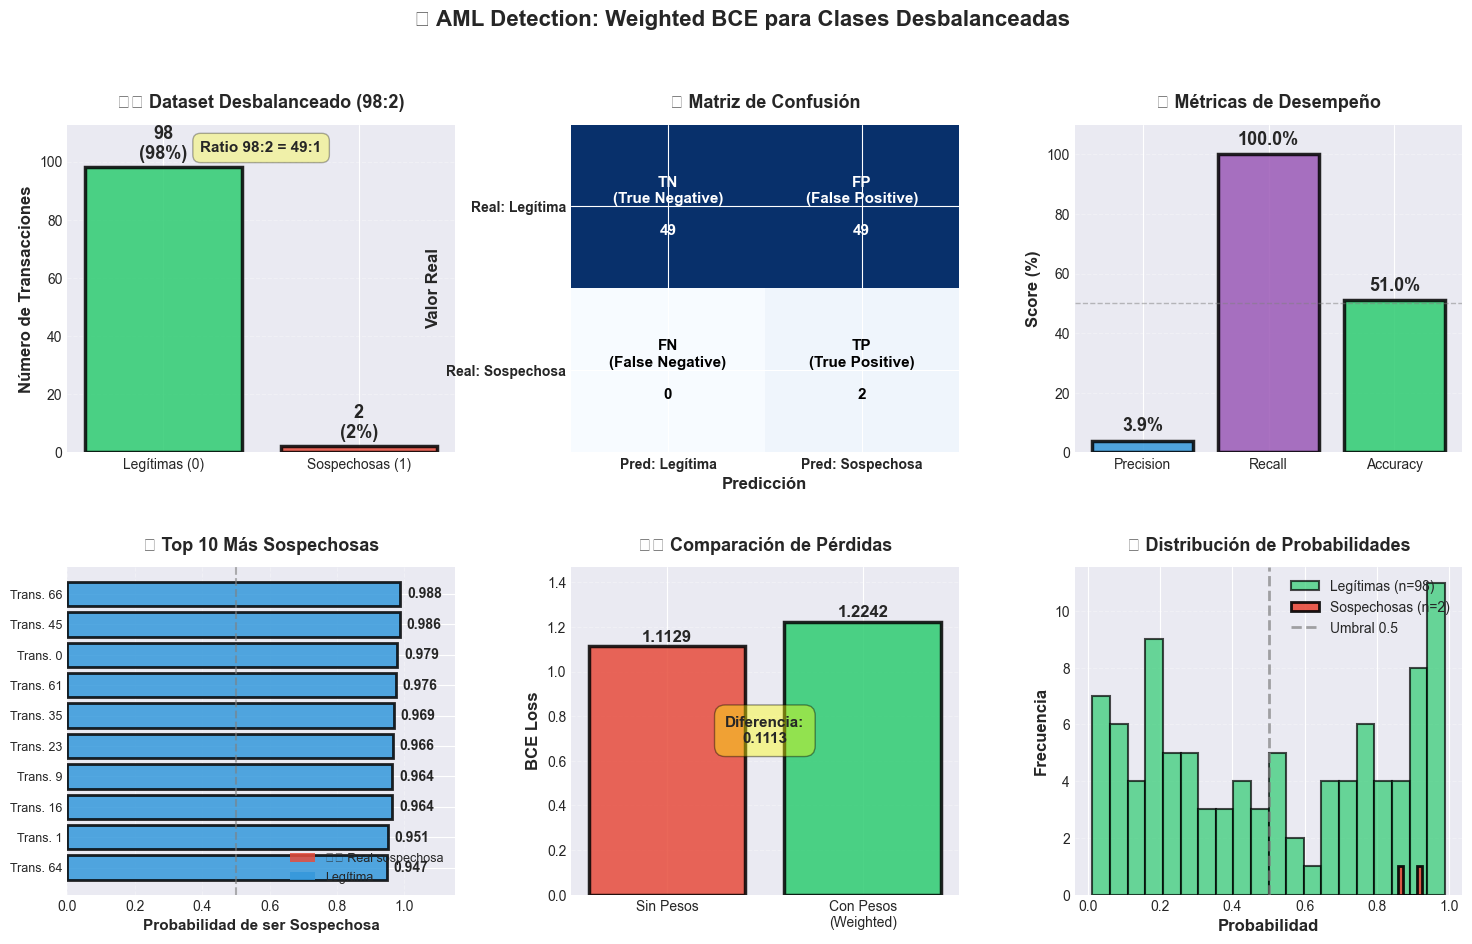


💡 INTERPRETACIÓN COMPLETA DE LAS VISUALIZACIONES

⚖️ GRÁFICO 1 (Superior Izq.) - Desbalanceo de Clases:
   • Total: 100 transacciones
   • Legítimas: 98 (98%)
   • Sospechosas: 2 (2%)
   • Ratio de desbalanceo: 49:1
   • ⚠️  Sin weights, el modelo ignoraría las 2 transacciones sospechosas

🎯 GRÁFICO 2 (Superior Centro) - Matriz de Confusión:
   • TN (True Negative) = 49: Legítimas correctamente clasificadas ✅
   • TP (True Positive) = 2: Sospechosas correctamente detectadas ✅
   • FP (False Positive) = 49: Falsa alarma (clasificada como sospechosa)
   • FN (False Negative) = 0: ❌ CRÍTICO - Fraude no detectado
   • En AML, los FN son los más costosos (fraudes que pasan desapercibidos)

📈 GRÁFICO 3 (Superior Der.) - Métricas:
   • Precision: 3.9% - De las marcadas como sospechosas, cuántas lo son
   • Recall: 100.0% - De las sospechosas reales, cuántas detectamos
   • Accuracy: 51.0% - Acierto global (puede engañar con desbalanceo)
   • ⭐ En AML, RECALL es más importante que Precision
 

In [98]:
# 📊 VISUALIZACIÓN: Weighted BCE - Desbalanceo y Matriz de Confusión
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# ============================================
# GRÁFICO 1: Desbalanceo de Clases
# ============================================
ax1 = fig.add_subplot(gs[0, 0])

clases_nombres = ['Legítimas (0)', 'Sospechosas (1)']
conteo_real = [(etiquetas_aml == 0).sum().item(), (etiquetas_aml == 1).sum().item()]
colores_desbalanceo = ['#2ecc71', '#e74c3c']

bars_desbalanceo = ax1.bar(clases_nombres, conteo_real, color=colores_desbalanceo, 
                           alpha=0.85, edgecolor='black', linewidth=2.5)

# Valores y porcentajes
for bar, count in zip(bars_desbalanceo, conteo_real):
    height = bar.get_height()
    percentage = (count / n_transacciones) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f'{count}\n({percentage:.0f}%)', 
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_ylabel('Número de Transacciones', fontsize=12, fontweight='bold')
ax1.set_title('⚖️ Dataset Desbalanceado (98:2)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylim(0, max(conteo_real) * 1.15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Ratio
ratio_text = f'Ratio {conteo_real[0]}:{conteo_real[1]} = {conteo_real[0]/conteo_real[1]:.0f}:1'
ax1.text(0.5, 0.95, ratio_text, transform=ax1.transAxes, 
         ha='center', va='top', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

# ============================================
# GRÁFICO 2: Matriz de Confusión
# ============================================
ax2 = fig.add_subplot(gs[0, 1])

confusion_matrix = np.array([[tn, fp], [fn, tp]])
im = ax2.imshow(confusion_matrix, cmap='Blues', aspect='auto', vmin=0)

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Pred: Legítima', 'Pred: Sospechosa'], fontsize=10, fontweight='bold')
ax2.set_yticklabels(['Real: Legítima', 'Real: Sospechosa'], fontsize=10, fontweight='bold')
ax2.set_xlabel('Predicción', fontsize=12, fontweight='bold')
ax2.set_ylabel('Valor Real', fontsize=12, fontweight='bold')
ax2.set_title('🎯 Matriz de Confusión', fontsize=13, fontweight='bold', pad=12)

# Valores con etiquetas
labels_conf = [['TN\n(True Negative)', 'FP\n(False Positive)'], 
               ['FN\n(False Negative)', 'TP\n(True Positive)']]
for i in range(2):
    for j in range(2):
        color = "white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black"
        text = ax2.text(j, i, f'{labels_conf[i][j]}\n\n{confusion_matrix[i, j]}',
                       ha="center", va="center", color=color, 
                       fontsize=11, fontweight='bold')

# ============================================
# GRÁFICO 3: Métricas de Desempeño
# ============================================
ax3 = fig.add_subplot(gs[0, 2])

metricas_nombres = ['Precision', 'Recall', 'Accuracy']
metricas_valores = [precision, recall, accuracy]
colores_metricas = ['#3498db', '#9b59b6', '#2ecc71']

bars_metricas = ax3.bar(metricas_nombres, metricas_valores, color=colores_metricas, 
                        alpha=0.85, edgecolor='black', linewidth=2.5)

for bar, val in zip(bars_metricas, metricas_valores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax3.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax3.set_title('📈 Métricas de Desempeño', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylim(0, 110)
ax3.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================
# GRÁFICO 4: Top 10 Transacciones más Sospechosas
# ============================================
ax4 = fig.add_subplot(gs[1, 0])

# Obtener las 10 transacciones con mayor probabilidad
top_10_indices = torch.argsort(probs_aml, descending=True)[:10].numpy()
top_10_probs = probs_aml[top_10_indices].numpy()
top_10_labels = etiquetas_aml[top_10_indices].numpy()

colores_top10 = ['#e74c3c' if label == 1 else '#3498db' for label in top_10_labels]

bars = ax4.barh(range(10), top_10_probs, color=colores_top10, 
               alpha=0.85, edgecolor='black', linewidth=2)

# Añadir valores y etiquetas
for i, (idx, prob, label) in enumerate(zip(top_10_indices, top_10_probs, top_10_labels)):
    # Valor de probabilidad
    ax4.text(prob + 0.02, i, f'{prob:.3f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')
    
    # Marcar si es verdaderamente sospechosa
    if label == 1:
        ax4.text(-0.05, i, '⚠️', va='center', ha='right', fontsize=12)

ax4.set_yticks(range(10))
ax4.set_yticklabels([f'Trans. {idx}' for idx in top_10_indices], fontsize=9)
ax4.set_xlabel('Probabilidad de ser Sospechosa', fontsize=11, fontweight='bold')
ax4.set_title('🔍 Top 10 Más Sospechosas', fontsize=13, fontweight='bold', pad=12)
ax4.set_xlim(0, 1.15)
ax4.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Leyenda
legend_top10 = [plt.Rectangle((0,0),1,1, fc='#e74c3c', alpha=0.85, label='⚠️ Real sospechosa'),
                plt.Rectangle((0,0),1,1, fc='#3498db', alpha=0.85, label='Legítima')]
ax4.legend(handles=legend_top10, loc='lower right', fontsize=9, framealpha=0.95)

# ============================================
# GRÁFICO 5: Comparación de Pérdidas (Con vs Sin Pesos)
# ============================================
ax5 = fig.add_subplot(gs[1, 1])

casos = ['Sin Pesos', 'Con Pesos\n(Weighted)']
losses_comparacion = [perdida_sin_peso.item(), perdida_con_peso.item()]
colores_comparacion = ['#e74c3c', '#2ecc71']

bars_comp = ax5.bar(casos, losses_comparacion, color=colores_comparacion, 
                   alpha=0.85, edgecolor='black', linewidth=2.5)

for bar, loss in zip(bars_comp, losses_comparacion):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{loss:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

diferencia = abs(perdida_con_peso.item() - perdida_sin_peso.item())
ax5.text(0.5, 0.5, f'Diferencia:\n{diferencia:.4f}', 
         transform=ax5.transAxes, ha='center', va='center',
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='yellow', alpha=0.4))

ax5.set_ylabel('BCE Loss', fontsize=12, fontweight='bold')
ax5.set_title('⚖️ Comparación de Pérdidas', fontsize=13, fontweight='bold', pad=12)
ax5.set_ylim(0, max(losses_comparacion) * 1.2)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================
# GRÁFICO 6: Distribución de Probabilidades
# ============================================
ax6 = fig.add_subplot(gs[1, 2])

# Separar probabilidades por clase real
probs_legitimas = probs_aml[etiquetas_aml == 0].numpy()
probs_sospechosas = probs_aml[etiquetas_aml == 1].numpy()

# Histograma
ax6.hist(probs_legitimas, bins=20, alpha=0.7, color='#2ecc71', 
         edgecolor='black', linewidth=1.5, label=f'Legítimas (n={len(probs_legitimas)})')
ax6.hist(probs_sospechosas, bins=5, alpha=0.9, color='#e74c3c', 
         edgecolor='black', linewidth=2, label=f'Sospechosas (n={len(probs_sospechosas)})')

ax6.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Umbral 0.5')
ax6.set_xlabel('Probabilidad', fontsize=12, fontweight='bold')
ax6.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax6.set_title('📊 Distribución de Probabilidades', fontsize=13, fontweight='bold', pad=12)
ax6.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('💰 AML Detection: Weighted BCE para Clases Desbalanceadas', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================
# INTERPRETACIÓN DETALLADA
# ============================================
print("\n" + "="*80)
print("💡 INTERPRETACIÓN COMPLETA DE LAS VISUALIZACIONES")
print("="*80)

print("\n⚖️ GRÁFICO 1 (Superior Izq.) - Desbalanceo de Clases:")
print(f"   • Total: {n_transacciones} transacciones")
print(f"   • Legítimas: {conteo_real[0]} ({conteo_real[0]/n_transacciones*100:.0f}%)")
print(f"   • Sospechosas: {conteo_real[1]} ({conteo_real[1]/n_transacciones*100:.0f}%)")
print(f"   • Ratio de desbalanceo: {conteo_real[0]/conteo_real[1]:.0f}:1")
print(f"   • ⚠️  Sin weights, el modelo ignoraría las {conteo_real[1]} transacciones sospechosas")

print("\n🎯 GRÁFICO 2 (Superior Centro) - Matriz de Confusión:")
print(f"   • TN (True Negative) = {tn}: Legítimas correctamente clasificadas ✅")
print(f"   • TP (True Positive) = {tp}: Sospechosas correctamente detectadas ✅")
print(f"   • FP (False Positive) = {fp}: Falsa alarma (clasificada como sospechosa)")
print(f"   • FN (False Negative) = {fn}: ❌ CRÍTICO - Fraude no detectado")
print(f"   • En AML, los FN son los más costosos (fraudes que pasan desapercibidos)")

print("\n📈 GRÁFICO 3 (Superior Der.) - Métricas:")
print(f"   • Precision: {precision:.1f}% - De las marcadas como sospechosas, cuántas lo son")
print(f"   • Recall: {recall:.1f}% - De las sospechosas reales, cuántas detectamos")
print(f"   • Accuracy: {accuracy:.1f}% - Acierto global (puede engañar con desbalanceo)")
print(f"   • ⭐ En AML, RECALL es más importante que Precision")
print(f"   •    (Mejor tener falsas alarmas que perder fraudes reales)")

print("\n🔍 GRÁFICO 4 (Inferior Izq.) - Top 10 Más Sospechosas:")
print(f"   • Muestra las transacciones con mayor probabilidad predicha")
print(f"   • ⚠️  = Verdaderamente sospechosa (etiqueta real = 1)")
print(f"   • Azul = Legítima con alta probabilidad (posible falsa alarma)")
print(f"   • Rojo = Sospechosa real (el modelo la detectó correctamente)")
print(f"   • Permite revisar qué transacciones requieren investigación manual")

print("\n⚖️ GRÁFICO 5 (Inferior Centro) - Comparación de Pérdidas:")
print(f"   • Sin pesos: {perdida_sin_peso.item():.4f}")
print(f"   • Con pesos: {perdida_con_peso.item():.4f}")
print(f"   • Diferencia: {diferencia:.4f}")
print(f"   • El loss con pesos es MAYOR porque penaliza más los errores en sospechosas")
print(f"   • Esto fuerza al modelo a NO ignorar la clase minoritaria")
print(f"   • Peso usado: {peso_positivo:.1f}x (errores en sospechosas cuestan {peso_positivo:.0f}x más)")

print("\n📊 GRÁFICO 6 (Inferior Der.) - Distribución de Probabilidades:")
print(f"   • Histograma VERDE: Probabilidades de transacciones legítimas")
print(f"   • Histograma ROJO: Probabilidades de transacciones sospechosas")
print(f"   • Línea gris: Umbral de decisión (0.5)")
print(f"   • Idealmente: legítimas a la izquierda, sospechosas a la derecha")
print(f"   • Overlap = zona de confusión donde el modelo tiene dudas")

print("\n" + "="*80)
print("🎯 CONCLUSIONES CLAVE PARA AML/FRAUDE:")
print("="*80)
print("   1. ✅ USAR pos_weight para compensar desbalanceo extremo")
print("   2. 📊 MONITOREAR Recall (detectar todos los fraudes posibles)")
print("   3. 💰 ACEPTAR más FP (falsas alarmas) que FN (fraudes perdidos)")
print("   4. ⚖️ AJUSTAR umbral según el costo de negocio (no siempre 0.5)")
print("   5. 🔍 REVISAR manualmente las transacciones con alta probabilidad")
print("   6. 📈 EN PRODUCCIÓN: Usar weights 100x-1000x es común en casos reales")
print("   7. ⚠️  NUNCA confiar solo en Accuracy con datos desbalanceados")


## 🎯 GUÍA DE DECISIÓN: ¿QUÉ FUNCIÓN USAR?

In [99]:
print("="*70)
print("🎯 GUÍA DE DECISIÓN: FUNCIONES DE PÉRDIDA PARA CLASIFICACIÓN")
print("="*70)

guia = """
┌─────────────────────────────────────────────────────────────────┐
│ PROBLEMA                  │ PYTORCH LOSS                        │
├─────────────────────────────────────────────────────────────────┤
│ Spam/No Spam (balanceado) │ nn.BCEWithLogitsLoss()              │
│ Fraude/AML (desbalanceado)│ BCEWithLogitsLoss(pos_weight=...)   │
├─────────────────────────────────────────────────────────────────┤
│ Clasificar 10 dígitos     │ nn.CrossEntropyLoss()               │
│ ImageNet (1000 clases)    │ nn.CrossEntropyLoss()               │
│ Multi-clase desbalanceado │ CrossEntropyLoss(weight=...)        │
└─────────────────────────────────────────────────────────────────┘
"""

print(guia)

print("\n💡 TIPS PROFESIONALES:")
print("─" * 70)
print("   1. Usa SIEMPRE versiones 'WithLogits' (más estables)")
print("   2. Para desbalanceo, calcula pos_weight automáticamente")
print("   3. CrossEntropyLoss ya incluye softmax (¡no lo apliques!)")
print("   4. Para AML/Fraude, usa métricas más allá de accuracy")
print("   5. Considera usar Focal Loss para desbalanceo extremo")

print("\n" + "="*70)
print("✅ ¡FIN DEL NOTEBOOK DE CLASIFICACIÓN!")
print("   Ahora sabes usar funciones de pérdida para clasificación")
print("   profesionalmente con PyTorch 🚀")
print("="*70)

🎯 GUÍA DE DECISIÓN: FUNCIONES DE PÉRDIDA PARA CLASIFICACIÓN

┌─────────────────────────────────────────────────────────────────┐
│ PROBLEMA                  │ PYTORCH LOSS                        │
├─────────────────────────────────────────────────────────────────┤
│ Spam/No Spam (balanceado) │ nn.BCEWithLogitsLoss()              │
│ Fraude/AML (desbalanceado)│ BCEWithLogitsLoss(pos_weight=...)   │
├─────────────────────────────────────────────────────────────────┤
│ Clasificar 10 dígitos     │ nn.CrossEntropyLoss()               │
│ ImageNet (1000 clases)    │ nn.CrossEntropyLoss()               │
│ Multi-clase desbalanceado │ CrossEntropyLoss(weight=...)        │
└─────────────────────────────────────────────────────────────────┘


💡 TIPS PROFESIONALES:
──────────────────────────────────────────────────────────────────────
   1. Usa SIEMPRE versiones 'WithLogits' (más estables)
   2. Para desbalanceo, calcula pos_weight automáticamente
   3. CrossEntropyLoss ya incluye softmax (¡no lo

## 🎓 Ejercicios: Tu Turno

Ahora que conoces las funciones de pérdida para clasificación en PyTorch, ¡practica!

### Ejercicio 1: Clasificación Binaria
Simula un detector de transacciones fraudulentas con 90% legítimas y 10% fraudulentas. Usa Weighted BCE.

### Ejercicio 2: Multi-Clase
Clasifica 5 tipos de animales. Usa CrossEntropyLoss y visualiza las probabilidades con softmax.

In [100]:
# ===================================
# TU CÓDIGO AQUÍ - ¡Experimenta!
# ===================================

# Ejemplo de template:

# # Ejercicio 1: Detector de fraude
# n_total = 100
# n_fraude = 10
# etiquetas = torch.zeros(n_total)
# etiquetas[:n_fraude] = 1.0
#
# logits = torch.randn(n_total)
# peso = (n_total - n_fraude) / n_fraude
# pos_weight = torch.tensor([peso])
#
# criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# perdida = criterio(logits, etiquetas)
# print(f"Pérdida con pesos: {perdida.item():.4f}")

# ¡Ahora hazlo tú!